
# Machine Learning with Scikit-Learn**

## Learning Objectives
* Load and inspect a real-world dataset using pandas to identify data types and missing values.
* Implement basic data cleaning techniques, such as imputing missing numerical values.
* Perform initial Exploratory Data Analysis (EDA) on numerical and categorical features using matplotlib and seaborn.
* Handle categorical features by applying One-Hot Encoding using scikit-learn's OneHotEncoder.
* Split the data into training and testing sets for model evaluation.
* Train a Machine Learning (Random Forest) Classifier for a binary classification problem.
* Evaluate the model using key metrics like the Confusion Matrix and Classification Report.
* Identify the importance of Feature Engineering/Selection and Class Imbalance in real-world ML problems.
* Apply the SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance and assess its impact on model performance.



In [ ]:
# For data manipulation
import numpy as np
import pandas as pd

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# For ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import plot_tree
from imblearn.over_sampling import SMOTE


In [ ]:
# Download some data https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data
!curl -L -o stroke-prediction-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/fedesoriano/stroke-prediction-dataset

!unzip stroke-prediction-dataset.zip
!ls

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 69007  100 69007    0     0  92663      0 --:--:-- --:--:-- --:--:-- 92663
Archive:  stroke-prediction-dataset.zip
replace healthcare-dataset-stroke-data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: healthcare-dataset-stroke-data.csv  
healthcare-dataset-stroke-data.csv  sample_data  stroke-prediction-dataset.zip


In [ ]:
# Load the data
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
# Explore the data (size, column names, data types, number of NaNs)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
# Deal with the missing data
bmi_median = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(bmi_median)

In [ ]:
# Define Features (X) and Target (y)
target = 'stroke'

# Identify Categorical and Numerical columns automatically
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()

print(f"Numerical Features: {numerical_cols}")
print(f"Categorical Features: {categorical_cols}")

Numerical Features: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
Categorical Features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


<Figure size 800x800 with 0 Axes>

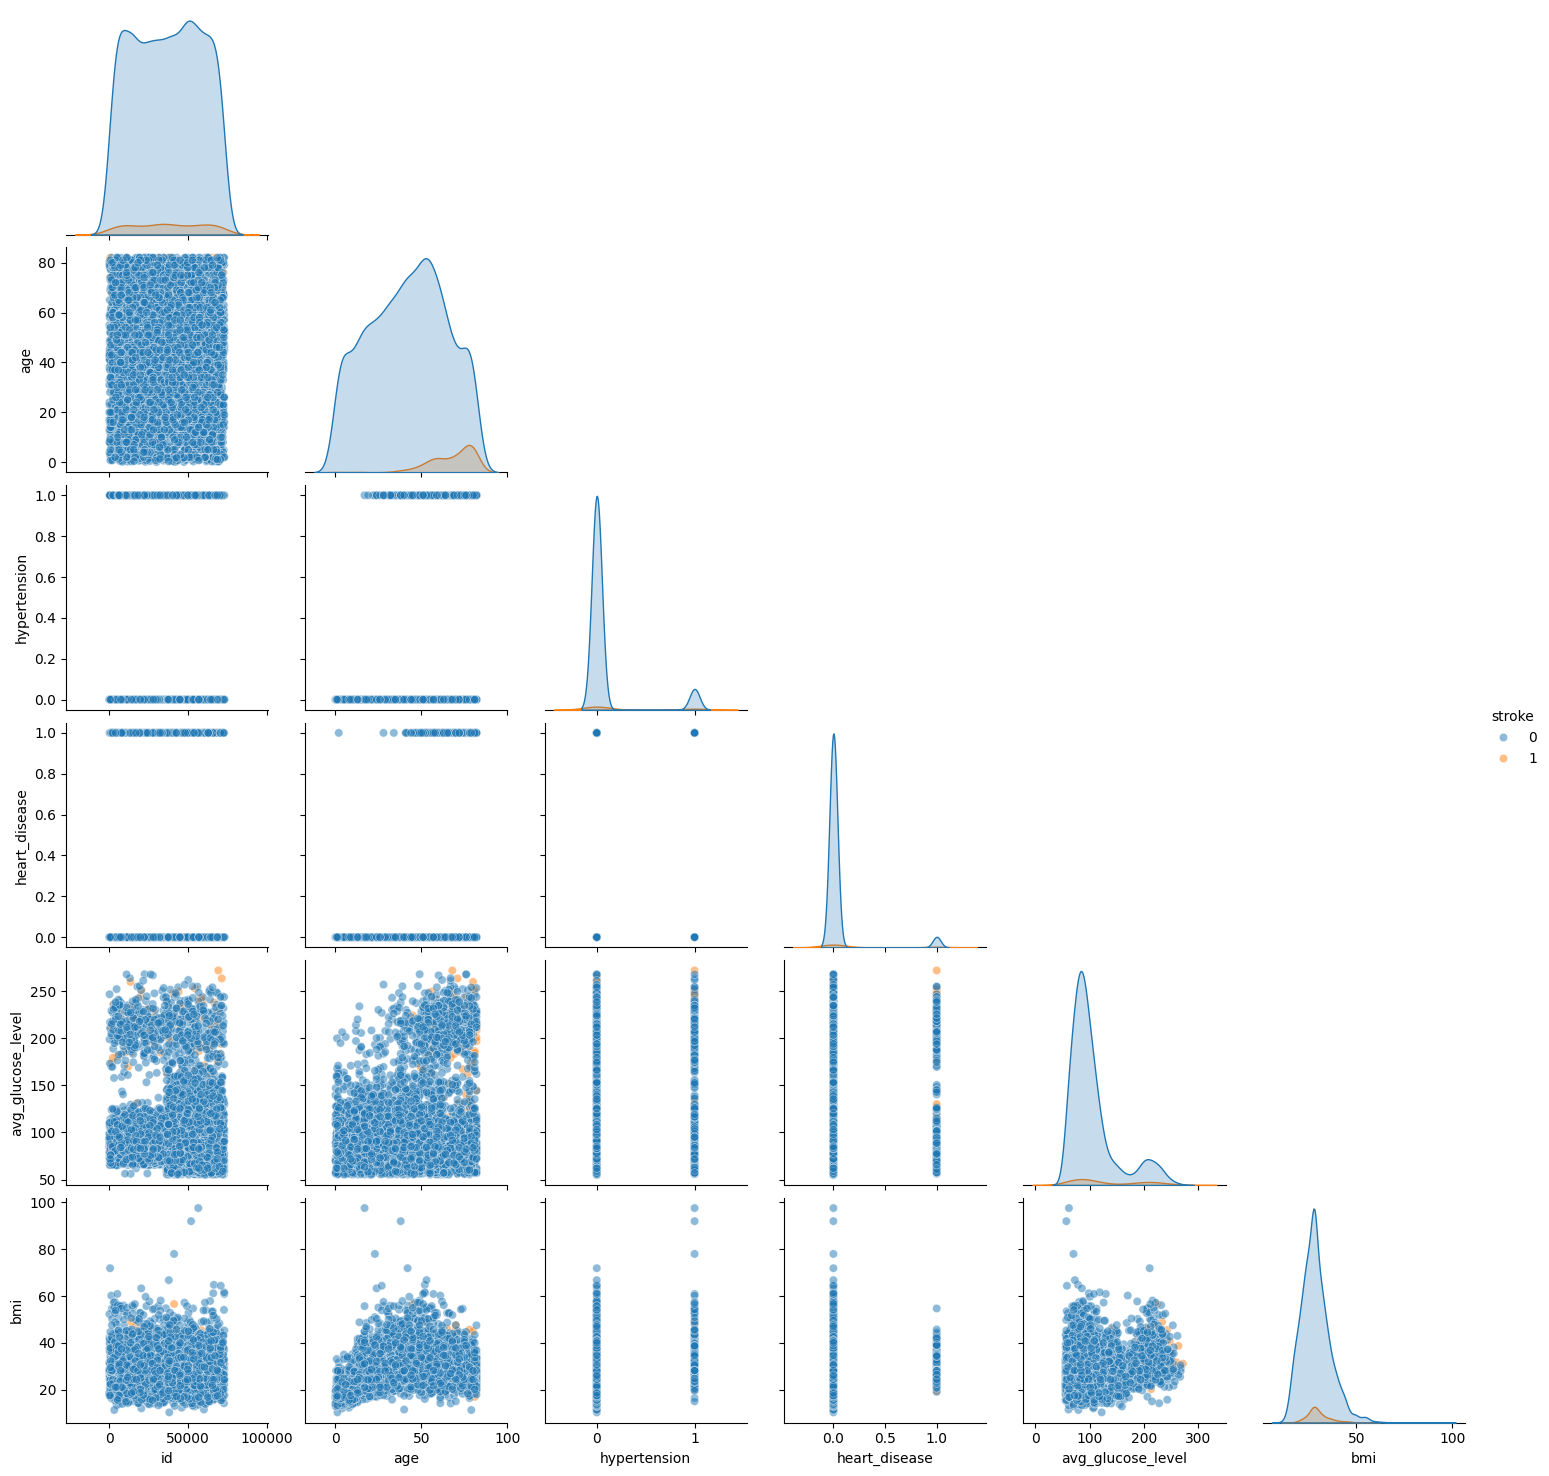

In [ ]:
plt.figure(figsize=(8, 8))
sns.pairplot(df[numerical_cols], hue='stroke',corner=True, plot_kws={'alpha': 0.5})
plt.show()

<Figure size 800x800 with 0 Axes>

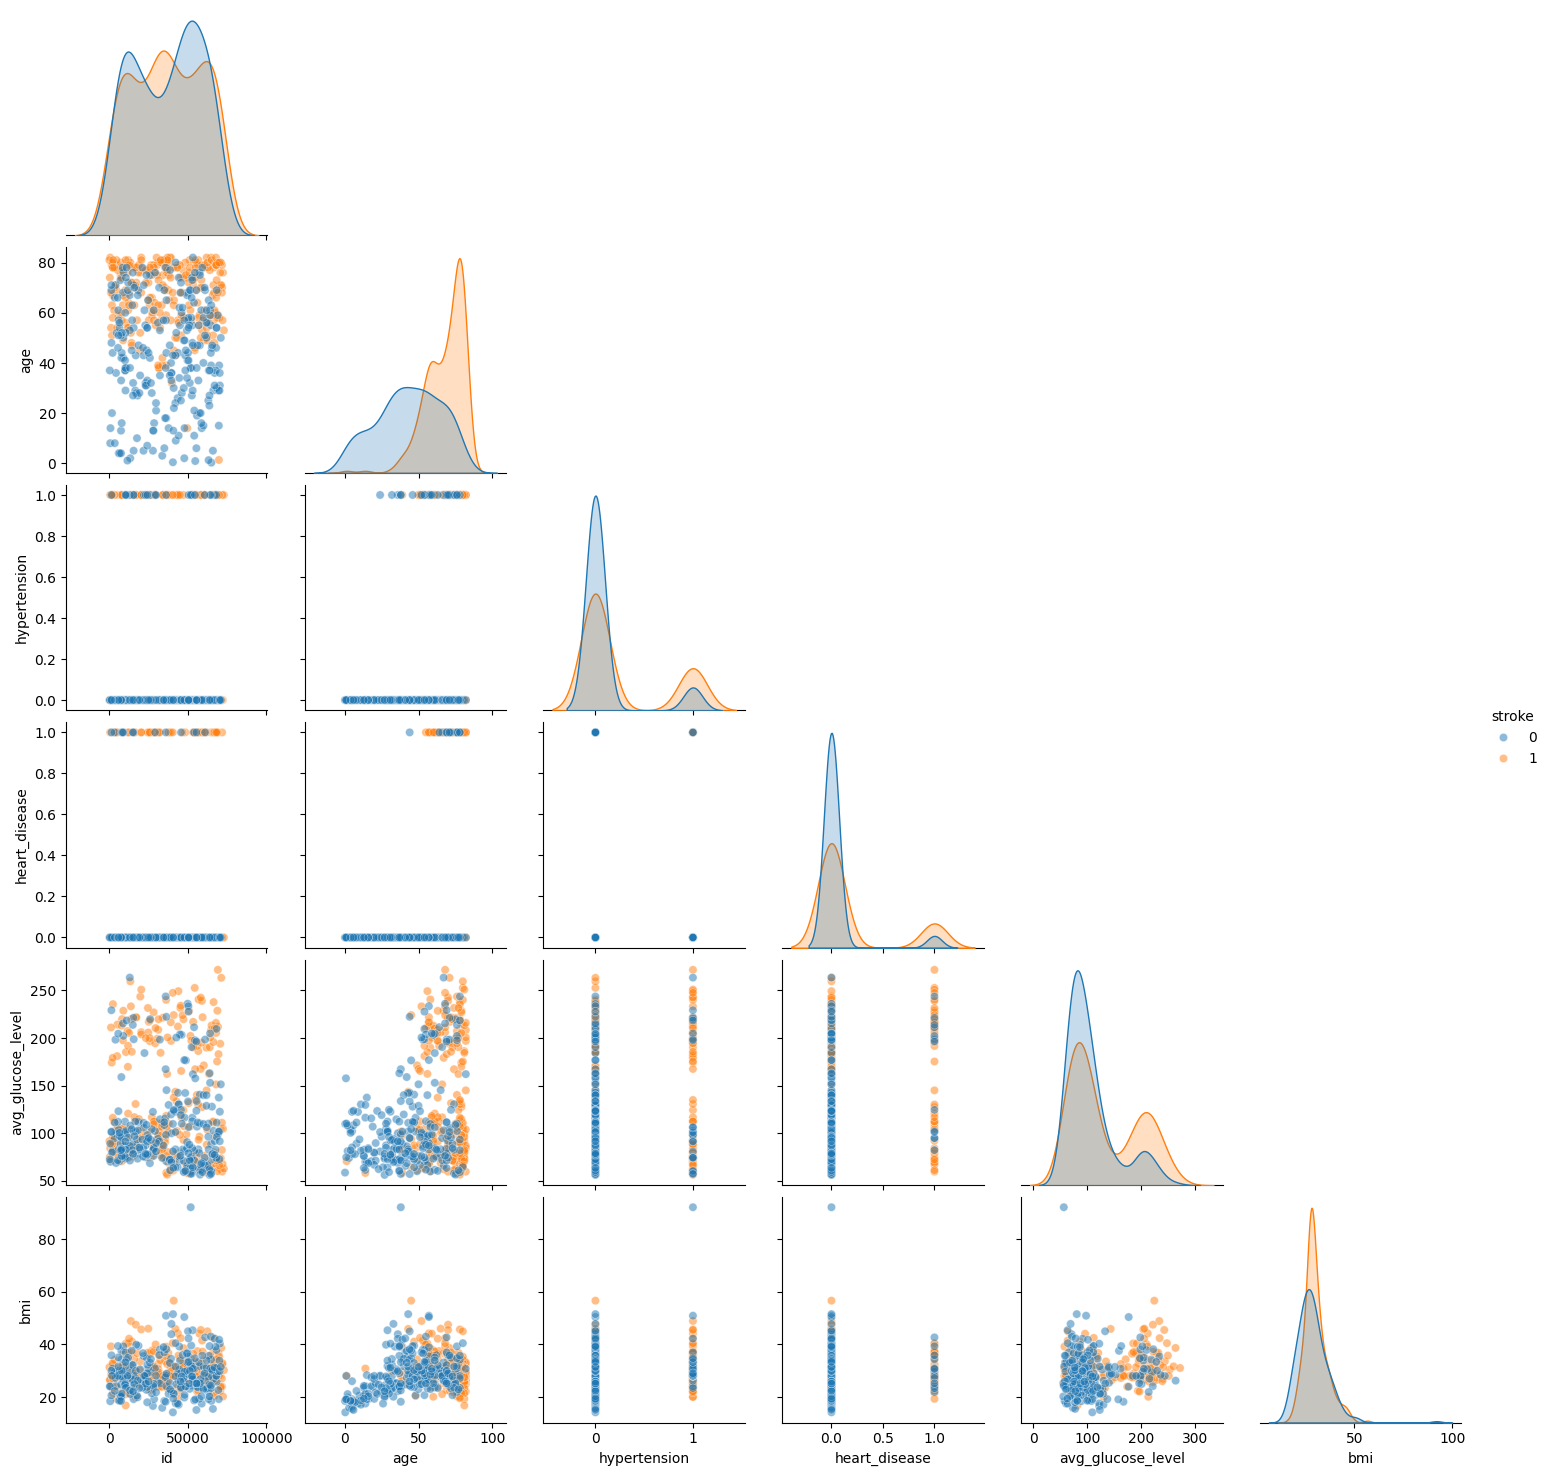

In [ ]:
# Just for plotting, we can undersample the 0 (no-stroke) class.
num_ones = df['stroke'].value_counts()[1]
df_zeros_sampled = df[df['stroke'] == 0].sample(n=num_ones, random_state=42)
df_ones = df[df['stroke'] == 1]
new_df = pd.concat([df_ones, df_zeros_sampled])

plt.figure(figsize=(8, 8))
sns.pairplot(new_df[numerical_cols], hue='stroke',corner=True, plot_kws={'alpha': 0.5})
plt.show()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64



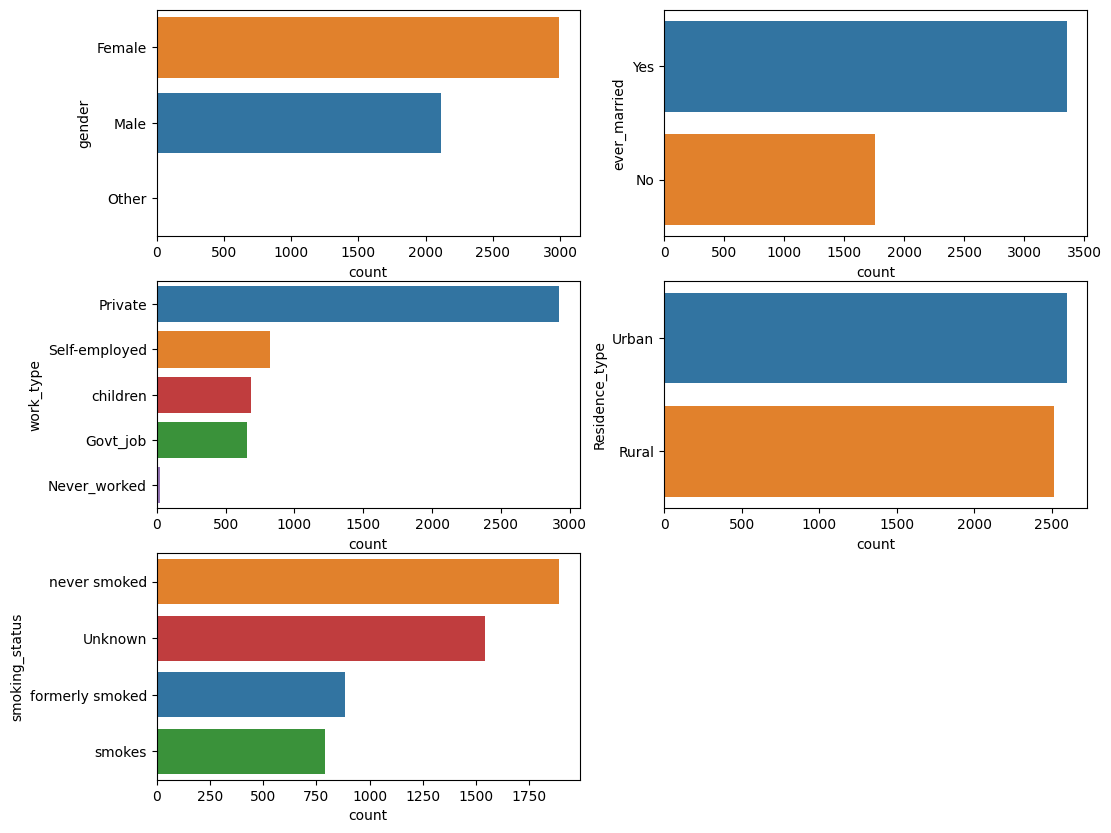

In [ ]:
# Deal with the categorical columns
plt.figure(figsize=(12, 10))
for i, feature in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1)
    sns.countplot(y=df[feature], data=df, order=df[feature].value_counts().index, hue=df[feature])
    print(f"{df[feature].value_counts()}\n")

plt.show()

In [ ]:
# Instantiate and Configure the OneHotEncoder
# We set 'sparse_output=False' so the output is a dense NumPy array,
# which is easier to convert directly into a pandas DataFrame.
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop='if_binary')

# Apply the encoding!
encoded_data = ohe.fit_transform(df[categorical_cols])

# 'get_feature_names_out' generates new meaningful column names (e.g., 'ever_married_Yes')
feature_names = ohe.get_feature_names_out(categorical_cols)

# create the New Encoded DataFrame
df_encoded = pd.DataFrame(encoded_data, columns=feature_names)
# df_encoded

In [ ]:
# Build the final dataframes we will use as target and feature vectors
X = pd.concat([df.drop(columns=categorical_cols+[target]+['id']),df_encoded],axis=1)

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Define the Machine Learning method and hyperparamters
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("Training Random Forest model...")
clf.fit(X_train, y_train)

# Predict
predictions = clf.predict(X_test)
print("Done!")

Training Random Forest model...
Done!


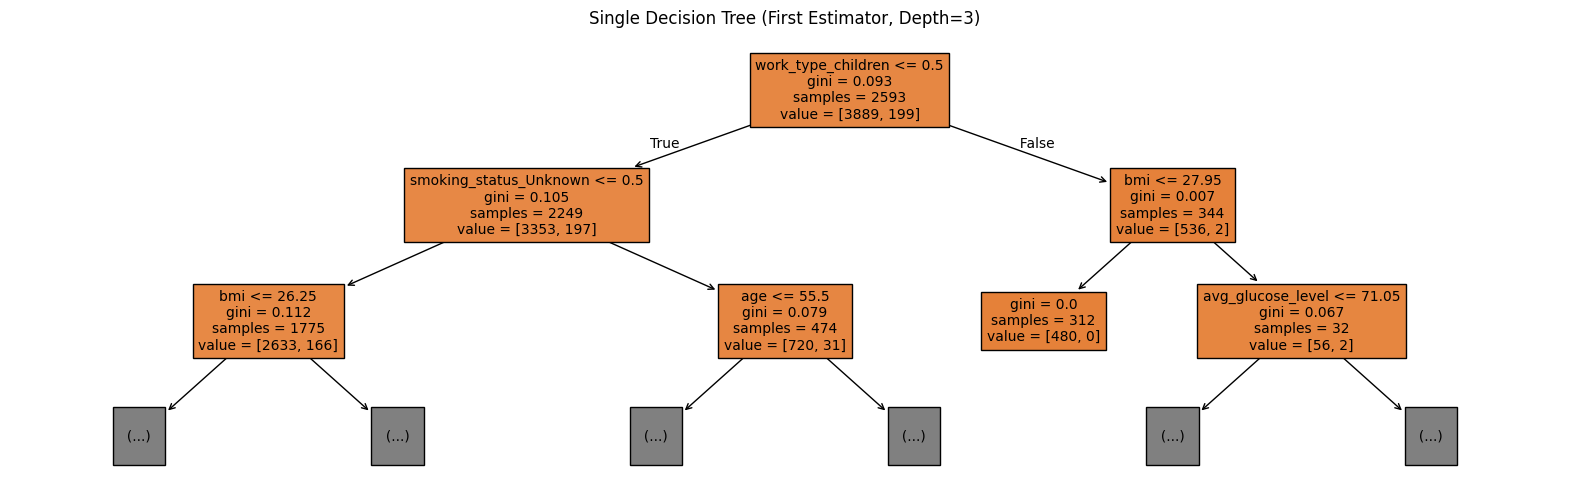

In [ ]:
plt.figure(figsize=(20, 6))
# Access the one of the trees (estimator) from the Random Forest
first_tree = clf.estimators_[0]

plot_tree(first_tree,
          feature_names=X.columns,
          filled=True,
          max_depth=2,  # Limit depth for readability
          fontsize=10)
plt.title("Single Decision Tree (First Estimator, Depth=3)")
plt.show()

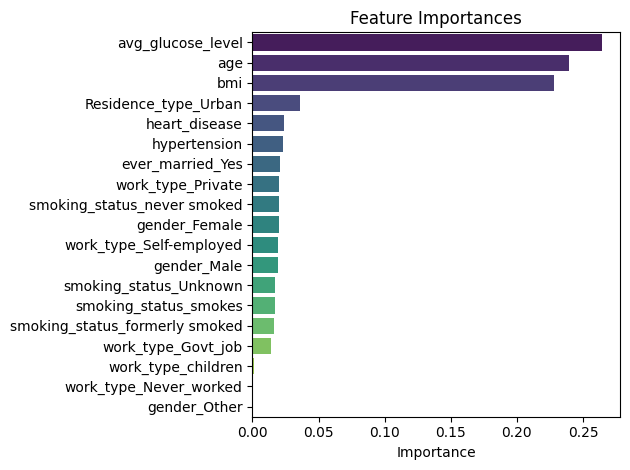

In [ ]:
# What features are being most used to train the model
# Get names for numerical features
feature_names = X_train.columns

# Get feature importances from the model
importances = clf.feature_importances_

# Create a DataFrame for plotting
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False) #.head(10) # Top 10 features

sns.barplot(x='Importance', y='Feature', data=fi_df, hue='Feature', palette='viridis', legend=False)
plt.title("Feature Importances")
plt.ylabel(None)

plt.tight_layout()
plt.show()

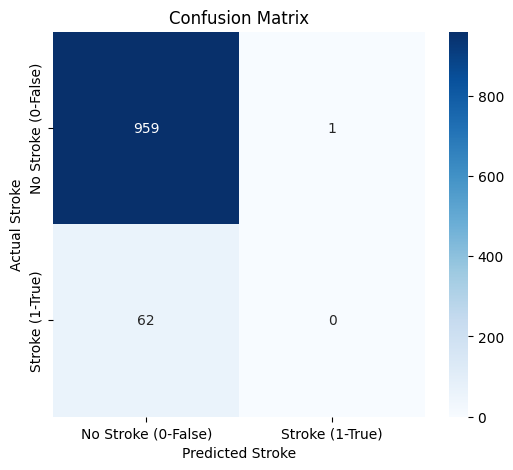


Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [ ]:
# How is the model performing
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke (0-False)', 'Stroke (1-True)'],
            yticklabels=['No Stroke (0-False)', 'Stroke (1-True)'])
plt.xlabel('Predicted Stroke')
plt.ylabel('Actual Stroke')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, predictions))

In [ ]:
# Let's fix the class imbalance
sm = SMOTE(random_state=42)

X_res, y_res = sm.fit_resample(X, y)

In [ ]:
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
clf_res = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_res, y_train_res)
predictions_res = clf.predict(X_test_res)

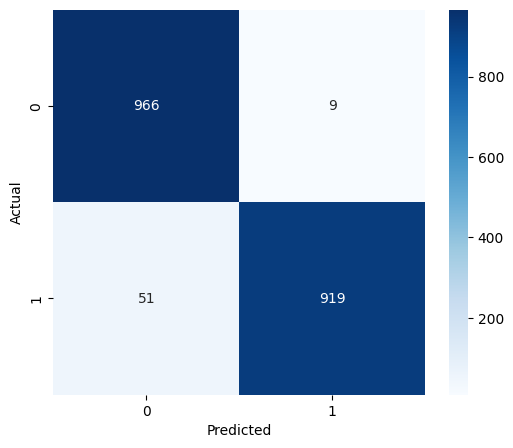


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       975
           1       0.99      0.95      0.97       970

    accuracy                           0.97      1945
   macro avg       0.97      0.97      0.97      1945
weighted avg       0.97      0.97      0.97      1945



In [ ]:
cm = confusion_matrix(y_test_res, predictions_res)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')#,
            # xticklabels=['At Risk', 'Healthy'],
            # yticklabels=['At Risk', 'Healthy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_res, predictions_res))